# Brown & Clark-ElSayed et al. (2026) — Peptide-responsive biosensors

Code and data tables for the heat-map panels in **"Design and characterization of peptide-responsive biosensors"** (D. M. Brown, A. Clark-ElSayed, T. M. Mott, B. G. Hendrickson, J. B. Lucks, A. D. Ellington).

This notebook was used to create **five** manuscript panels:

| Cell | Manuscript panel | Data table | Output |
|---|---|---|---|
| 1 | Fig. 1c — ligand specificity | `Ligand_Specificity_Heatmap.xlsx` | `Ligand_Specificity_Heatmap.svg` |
| 2 | Fig. 1d — promoter specificity | `Promoter_Specificity_Heatmap.xlsx` | `Promoter_Specificity_Heatmap.svg` |
| 3 | Fig. 4a — cell-free translated alanine scan | `WT_DNA_Alanine_Scan_Heatmap.xlsx` | `WT_DNA_Alanine_Scan_Heatmap.svg` |
| 4 | Fig. 4b — cellular translated alanine scan | `Cellular_Alanine_Scan_Revised.xlsx` | `Ceullular_Arabinose_Alanine_Scan_Revised_Heatmap.svg` |
| 5 | Fig. 4d — SSM peptide variant dose-responses | `Cellular_Peptide_Variants_Combined.xlsx` | `Ceullular_Peptide_Variants_Medium_Combined.svg` |

All other panels in the paper (dose-response curves, bar charts, schematics, and every supplementary figure) were produced outside this notebook and are not reproduced here. Each `.xlsx` in this repository is the plotting summary table for one panel; data is also contained in the Supplementary Excel files that accompany the manuscript (`Figure_1_Data.xlsx`, `Figure_4_Data.xlsx`, `SI_Data_Compiled.xlsx`).

**Paths are relative.** Run the notebook with this folder as the working directory; every table is read from, and every SVG written to, the notebook's own directory.

In [15]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# All data tables and figure outputs live alongside this notebook.
DATA_DIR = Path.cwd()

# Shared white -> green gradient used for every panel in the paper.
PALETTE = ["#FFFFFF", "#7BC797"]

def cmap(n):
    """Build the manuscript colormap with `n` quantization levels."""
    return LinearSegmentedColormap.from_list("custom_gradient", PALETTE, N=n)

def load_matrix(filename):
    """Read a plotting summary table.

    Every table is stored as conditions-in-rows x TF/variant-in-columns, with
    standard deviations in paired columns whose names contain 'Error'. Those
    error COLUMNS are dropped, and the matrix is transposed so that the
    heat map is drawn in the orientation used in the figures.
    """
    data = pd.read_excel(DATA_DIR / filename, index_col=0)
    data = data.loc[:, ~data.columns.str.contains("Error", case=False)]
    return data.T

def save(filename):
    """Write the current figure as an SVG next to the notebook."""
    out = DATA_DIR / filename
    plt.savefig(out, format="svg", bbox_inches="tight")
    print(f"wrote {out}")

print(f"working directory: {DATA_DIR}")

working directory: /Users/dylan/Downloads/GITHUB 3


## Figure 1c — Ligand specificity of the cell-free RRNPP biosensors

**Panel.** Heat map of cross-reactivity between the RRNPP transcription factors and the synthetic pheromone peptides, showing that Rgg2 and Rgg3 both respond to SHP2 and SHP3 while ComR-ST and ComR-SI respond only to their cognate XIP peptides.

**Data file — `Ligand_Specificity_Heatmap.xlsx`.** A 5 x 5 matrix: rows are the synthetic peptides (SHP2, SHP3, XIP-ST, XIP-SI, PapR), columns alternate between a transcription factor (Rgg2, Rgg3, ComR-ST, ComR-SI, PlcR)  Values are the endpoint (t = 600 min) sfGFP signal standardized to MEF (µM FITC), averaged over n = 3 experimental replicates; 

**Conditions.** 375 µM synthetic peptide, 50 nM reporter DNA, 9% (v/v) TF CFPS in *E. coli* lysate.

**Provenance.** Identical to the *"Average endpoint signal for ligand specificity matrix (t = 600 min)"* summary block of sheet `Figure_1_C` in the supplementary `Figure_1_Data.xlsx`, which also holds the raw kinetic traces this table was condensed from. PlcR is present in the table because it was assayed alongside the others; the published panel presents Rgg2, Rgg3, ComR-ST and ComR-SI.

wrote /Users/dylan/Downloads/GITHUB 3/Ligand_Specificity_Heatmap.svg


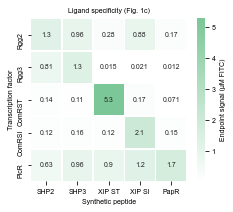

In [2]:
data = load_matrix("Ligand_Specificity_Heatmap.xlsx")

plt.figure(figsize=(3.5, 3))
plt.rc("font", family="Arial", size=7)

sns.heatmap(
    data,
    annot=True,
    cmap=cmap(256),
    cbar_kws={"label": "Endpoint signal (µM FITC)"},
    linewidths=0.5,
)
plt.title("Ligand specificity (Fig. 1c)", fontsize=7)
plt.xlabel("Synthetic peptide", fontsize=7)
plt.ylabel("Transcription factor", fontsize=7)

save("Ligand_Specificity_Heatmap.svg")
plt.show()

## Figure 1d — Promoter specificity of the cell-free RRNPP biosensors

**Panel.** Heat map of each transcription factor assayed against every RRNPP promoter, showing that Rgg2 and Rgg3 function on each other's promoters while ComR-ST and ComR-SI work only with their cognate promoters.

**Data file — `Promoter_Specificity_Heatmap.xlsx`.** A 6 x 5 matrix: six reporter conditions by five transcription factors. Values are endpoint (t = 600 min) signal in µM FITC, n = 3 experimental replicates. 

**Conditions.** 375 µM cognate peptide, 50 nM reporter DNA, 9% (v/v) TF CFPS.

**Provenance.** Values are identical to the *"Average endpoint signal for promoter specificity matrix (t = 600 min)"* block of sheet `Figure_1_D` in `Figure_1_Data.xlsx`.


wrote /Users/dylan/Downloads/GITHUB 3/Promoter_Specificity_Heatmap.svg


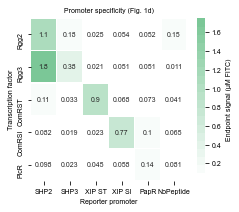

In [16]:
data = load_matrix("Promoter_Specificity_Heatmap.xlsx")

plt.figure(figsize=(3.5, 3))
plt.rc("font", family="Arial", size=7)

sns.heatmap(
    data,
    annot=True,
    cmap=cmap(20),
    cbar_kws={"label": "Endpoint signal (µM FITC)"},
    linewidths=0.5,
)
plt.title("Promoter specificity (Fig. 1d)", fontsize=7)
# Columns are promoters; see the label note above.
plt.xlabel("Reporter promoter", fontsize=7)
plt.ylabel("Transcription factor", fontsize=7)

save("Promoter_Specificity_Heatmap.svg")
plt.show()

## Figure 4a — Alanine scan of SHP3, cell-free translated peptides

**Panel.** Single-row heat map of Rgg3 activation by each member of the SHP3 alanine-scan library, with the peptide supplied as a DNA template and translated in the cell-free reaction. Alanine substitution at any of the four isoleucines (I3, I4, I5, I6) abolishes activation; the termini are more tolerant.

**Data file — `WT_DNA_Alanine_Scan_Heatmap.xlsx` Signal is fold activation normalized to 1, n = 3 experimental replicates.


**Conditions.** 50 nM reporter template DNA, 80 nM peptide DNA, 9% (v/v) Rgg3 CFPS.

**Provenance.** Condensed from the raw kinetic traces in sheet `Figure_4_A` of `Figure_4_Data.xlsx`

wrote /Users/dylan/Downloads/GITHUB 3/WT_DNA_Alanine_Scan_Heatmap.svg


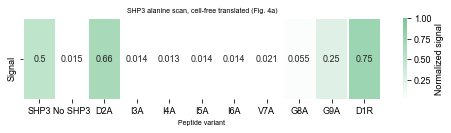

In [19]:
data = load_matrix("WT_DNA_Alanine_Scan_Heatmap.xlsx")

plt.figure(figsize=(8, 1.5))
plt.rc("font", family="Arial", size=9)

sns.heatmap(
    data,
    annot=True,
    cmap=cmap(625),
    cbar_kws={"label": "Normalized signal"},
    linewidths=0.5,
    vmax=1,
)
plt.title("SHP3 alanine scan, cell-free translated (Fig. 4a)", fontsize=7)
plt.xlabel("Peptide variant", fontsize=7)
plt.ylabel("", fontsize=7)

save("WT_DNA_Alanine_Scan_Heatmap.svg")
plt.show()

## Figure 4b — Alanine scan of SHP3, cellular translated peptides

**Panel.** Heat map of the same SHP3 alanine-scan library expressed in *E. coli* DH10B from a pBAD promoter, read across an arabinose induction series. The in vivo result reproduces the cell-free scan: the isoleucine positions are essential, D2A is tolerated and modestly increases activation over wild-type SHP3.

**Data file — `Cellular_Alanine_Scan_Revised.xlsx`.** Eleven rows x eight columns. Columns `Conc 1`–`Conc 8` are the arabinose induction series **0, 0.0005, 0.001, 0.0025, 0.005, 0.05, 0.1 and 0.2 % (w/v)**. Values are sfGFP fluorescence normalized to cell density (RFU/OD), averaged over n = 3 biological replicates.

Rows: `Rgg3 + SHP3` is the wild-type circuit; `SHP3` (peptide, no transcription factor) and `Rgg3` (transcription factor, no peptide) are the two negative controls

**Provenance.** Identical to the *"Table of Averages"* block of sheet `Figure_4_B` in `Figure_4_Data.xlsx`


wrote /Users/dylan/Downloads/GITHUB 3/Ceullular_Arabinose_Alanine_Scan_Revised_Heatmap.svg


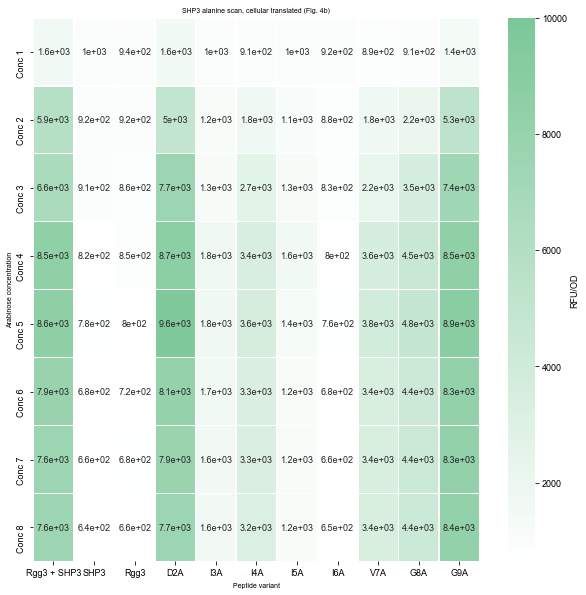

In [21]:
data = load_matrix("Cellular_Alanine_Scan_Revised.xlsx")

plt.figure(figsize=(10, 10))
plt.rc("font", family="Arial", size=9)

sns.heatmap(
    data,
    annot=True,
    cmap=cmap(256),
    cbar_kws={"label": "RFU/OD"},
    linewidths=0.5,
    vmax=10000,
)
plt.title("SHP3 alanine scan, cellular translated (Fig. 4b)", fontsize=7)
plt.xlabel("Peptide variant", fontsize=7)
plt.ylabel("Arabinose concentration", fontsize=7)

save("Ceullular_Arabinose_Alanine_Scan_Revised_Heatmap.svg")
plt.show()

## Figure 4d — Dose-responses of SHP3 variants from the site-saturation screen

**Panel.** Heat map of arabinose dose-responses for the peptide variants recovered from the single-position site-saturation mutagenesis (SSM) screen, pooling the high-activity and medium-activity colony picks. Substitutions that retain near wild-type activation were recovered at every position; conservative changes at the buried isoleucines (I3L, I4T, I5V, I5L, I6L) behave like wild type, while the less conservative picks (I3R, I4D, I4E, I5F) are markedly weaker.

**Data file — `Cellular_Peptide_Variants_Combined.xlsx`.** Twenty-eight rows x eight columns. Columns `Conc 1`–`Conc 8` are the same arabinose series as Fig. 4b (**0, 0.0005, 0.001, 0.0025, 0.005, 0.05, 0.1, 0.2 %**). Values are RFU/OD, n = 3 biological replicates.

Rows, in order:

- **Controls** — `WT SHP3` (wild-type circuit), `SHP3` (no transcription factor), `Rgg3` (no peptide).
- **High-activity screen** (bright colonies on 0.005 % arabinose, Supplementary Table 2) — D2R, D2A, I3L, I4T, I5V, I5L, I6L, V7T, G8T, G8H, G9M, G9I.
- **Medium-activity screen** (dimmer colonies, ~2.5–4.5-fold change, Supplementary Table 3) — D2L, D2G, I3R, I3S, I4D, I4E, I5F, I5A, I6T, I6F, V7M, G8W, G9N.

**Provenance.** Verified numerically identical to the *"Cellular Averages"* block of sheet `Figure_4_D` in `Figure_4_Data.xlsx`, which additionally lists the fitted Hill coefficients and EC50 values for each variant.



wrote /Users/dylan/Downloads/GITHUB 3/Ceullular_Peptide_Variants_Medium_Combined.svg


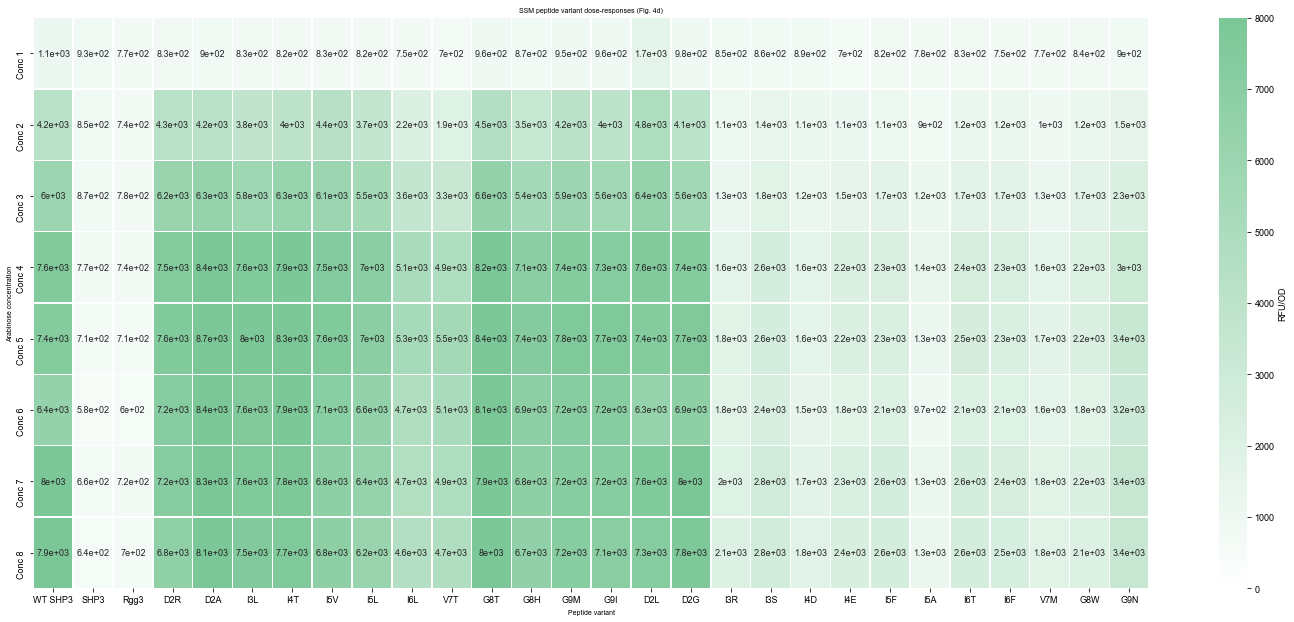

In [14]:
data = load_matrix("Cellular_Peptide_Variants_Combined.xlsx")

plt.figure(figsize=(25, 10.5))
plt.rc("font", family="Arial", size=9)

sns.heatmap(
    data,
    annot=True,
    cmap=cmap(256),
    cbar_kws={"label": "RFU/OD"},
    linewidths=0.5,
    vmin=0,
    vmax=8000,
)
plt.title("SSM peptide variant dose-responses (Fig. 4d)", fontsize=7)
plt.xlabel("Peptide variant", fontsize=7)
plt.ylabel("Arabinose concentration", fontsize=7)

save("Ceullular_Peptide_Variants_Medium_Combined.svg")
plt.show()